In [24]:
import os
os.chdir('../../..')

In [65]:
import chemiscope
import matplotlib.pyplot as plt
import numpy as np

from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, MDS
from sklearn.metrics import silhouette_score
from umap import UMAP

from tqdm import tqdm

from src.datasets import QM9Dataset

In [112]:
qm9 = QM9Dataset()
qm9.load()

qm9.add_morgan_fingerprints()
qm9.add_selfies_transformer()
qm9.add_chemprop()
qm9.add_soap()
qm9.add_acsf()

frames = qm9.get_positions()

qm9.df.head(3)

2026-03-18 18:21:24.362 | INFO     | src.datasets:load:381 - Loading QM9 from data/QM9/dataset_cleaned.csv...
2026-03-18 18:21:24.405 | INFO     | src.features:compute_morgan_fingerprints:57 - Computing Morgan Fingerprints (Radius=3, Size=2048)...
2026-03-18 18:21:26.434 | INFO     | src.features:compute_selfies_transformer:74 - Computing SELFormer Embeddings using HUBioDataLab/SELFormer...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

2026-03-18 18:21:41.337 | INFO     | src.features:compute_chemprop_embeddings:254 - Computing Chemprop embeddings on mps...
2026-03-18 18:21:41.338 | WARNING  | src.features:compute_chemprop_embeddings:262 - No model_path provided. Using RANDOM (untrained) MPNN weights.
2026-03-18 18:21:41.896 | INFO     | src.features:compute_soap:144 - Computing SOAP (rcut=6.0, nmax=8, lmax=6)...
2026-03-18 18:21:47.318 | SUCCESS  | src.datasets:add_soap:603 - Added SOAP embeddings.
2026-03-18 18:21:47.318 | INFO     | src.features:compute_acsf:174 - Computing ACSF (rcut=6.0)...
2026-03-18 18:21:51.508 | SUCCESS  | src.datasets:add_acsf:614 - Added ACSF embeddings.
2026-03-18 18:21:54.370 | SUCCESS  | src.datasets:get_positions:928 - Saved 2000 molecules to data/QM9/qm9_subset.xyz (failed: 0, requested: 2000).


mol_id,formula,smiles,canonical_smiles,selfies,functional_groups,num_atoms,structure_class,mol_weight,logp,tpsa,num_heavy_atoms,num_rings,num_aromatic_rings,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,fr_halogen,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,morgan_fingerprint,selfies_transformer,chemprop_embedding,soap_embedding,acsf_embedding
str,str,str,str,str,str,i64,str,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,list[i8],list[f64],list[f64],list[f64],list[f64]
"""qm9_2""","""H2O""","""[H]O[H]""","""[H]O[H]""","""[H][O][H]""","""""",3,"""Acyclic""",18,0,31,1,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,2,3,0.980759,0,0,0,0,0,0,0,0,0,0,1,1.8511,6.31,-7.967494,1.869422,9.836916,19.0002,0.581643,-2079.077881,-2079.000732,-2078.975098,-2079.558105,6.002,-9.240362,-9.278811,-9.330214,-8.733849,799.588135,437.90387,282.945465,"[0, 0, … 0]","[1.035763, 0.256207, … 0.323382]","[0.0, 0.0, … 0.0]","[0.150713, 0.392522, … 0.0]","[1.190363, 1.052614, … 0.0]"
"""qm9_3""","""C2H2""","""[H]C#C[H]""","""[H]C#C[H]""","""[H][C][#C][H]""","""""",4,"""Acyclic""",26,0,0,2,0,0,0,1.0,0.0,0.0,0,0,0,2,0,0,3,4,1.105607,0,0,0,0,0,0,0,0,0,0,0,0.0,16.280001,-7.741639,1.376896,9.118535,59.524799,0.730381,-2103.669434,-2103.590576,-2103.564697,-2104.186523,8.574,-16.716963,-16.792231,-16.869347,-15.862634,0.0,35.610035,35.610035,"[0, 0, … 0]","[1.47265, 0.608035, … 0.116478]","[0.0, 0.032312, … 0.0]","[0.116808, 0.322429, … 0.0]","[1.012563, 0.530161, … 0.0]"
"""qm9_4""","""CHN""","""[H]C#N""","""[H]C#N""","""[H][C][#N]""","""""",3,"""Acyclic""",27,0,23,2,0,0,0,1.0,0.0,0.0,0,1,0,1,0,0,2,3,1.092491,0,0,0,0,0,0,0,0,0,0,1,2.8937,12.99,-9.806983,0.519737,10.329442,48.747601,0.451736,-2541.866943,-2541.79834,-2541.772705,-2542.393555,6.278,-13.088188,-13.13529,-13.186666,-12.520096,0.0,44.593884,44.593884,"[0, 0, … 0]","[0.546197, 0.145142, … -0.164353]","[0.0, 0.080962, … 0.027528]","[0.077737, 0.214865, … 0.0]","[0.540542, 0.358622, … 0.0]"


# Tanimoto distance clustering on Morgan Fingerprints

In [114]:
def print_silhouette_scores(X, metric='jaccard', k_max=15, linkage='average'):
    scores = []

    for k in tqdm(range(2,k_max), desc='Processing number of clusters)'):
        model = AgglomerativeClustering(
            n_clusters=k,
            metric=metric,
            linkage=linkage
        )
        
        labels = model.fit_predict(X)
        
        score = silhouette_score(X, labels, metric=metric)
        scores.append(score)
    
    plt.plot([i for i in range(2,k+1)], scores)
        
    print(f"Best silhouette score is at: {[i+2 for i, score in enumerate(scores) if score == max(scores)][0]} being {max(scores)}")
    return scores

Processing number of clusters): 100%|██████████| 2/2 [00:11<00:00,  5.80s/it]

Best silhouette score is at: 2 being 0.058383029970018756


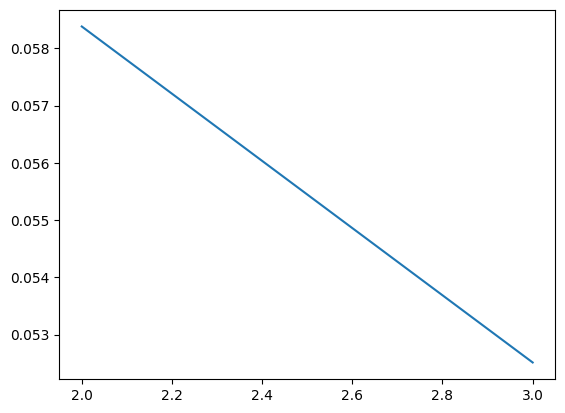

In [87]:
X = np.array(qm9.df["morgan_fingerprint"].to_list())
X_bool = (X == 1)

scores = print_silhouette_scores(X_bool, 4)

In [66]:
cluster_model = AgglomerativeClustering(
    n_clusters=6, 
    metric='jaccard', 
    linkage='average'
)

labels = cluster_model.fit_predict(X)

unique, counts = np.unique(labels, return_counts=True)

print(unique)
print(counts)

[0 1 2 3 4 5]
[894 290 812   1   1   2]


In [67]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init="pca")
X_tsne = tsne.fit_transform(X)

reducer = UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
X_umap = reducer.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

mds = MDS(n_components=2, random_state=42, normalized_stress='auto')
X_mds = mds.fit_transform(X)

/Users/karlfindhansen/Desktop/DTU/Kandidat/Thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/karlfindhansen/Desktop/DTU/Kandidat/Thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/Users/karlfindhansen/Desktop/DTU/Kandidat/Thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


In [69]:
properties = {
    "UMAP 1": X_pca[:, 0],
    "UMAP 2": X_pca[:, 1],
    "Cluster": labels,
    "Structure": qm9.df["structure_class"].to_list(),
    "Functional Groups": qm9.df["functional_groups"].to_list(),
    "SP1 Carbon" : qm9.df["num_sp_carbons"].to_list(),
    "SP2 Carbon" : qm9.df["num_sp2_carbons"].to_list(),
    "SP3 Carbon" : qm9.df["num_sp3_carbons"].to_list(),
    "Avg Bond length": qm9.df["avg_bond_length"].to_list(),
}

widget = chemiscope.show(
    structures=frames,
    properties=properties,
)

widget

<ChemiscopeWidget(meta={'name': ' '}, structures=[{'size': 3, 'data': 'structure-0'}, {'size': 4, 'data': 'str…

# Chemprop and Transformer embedding
- Using Cosine Distance 

In [107]:
X_chemprop = np.array(qm9.df["chemprop_embedding"].to_list())
X_transformer = np.array(qm9.df["selfies_transformer"].to_list())

In [134]:
from sklearn.preprocessing import normalize
X_chemprop = normalize(X_chemprop, norm='l2', axis=1)
X_transformer = normalize(X_transformer, norm='l2', axis=1)

Processing number of clusters): 100%|██████████| 13/13 [00:07<00:00,  1.83it/s]


Best silhouette score is at: 2 being 0.7835369503929801


Processing number of clusters): 100%|██████████| 13/13 [00:20<00:00,  1.56s/it]

Best silhouette score is at: 2 being 0.5940160915059078


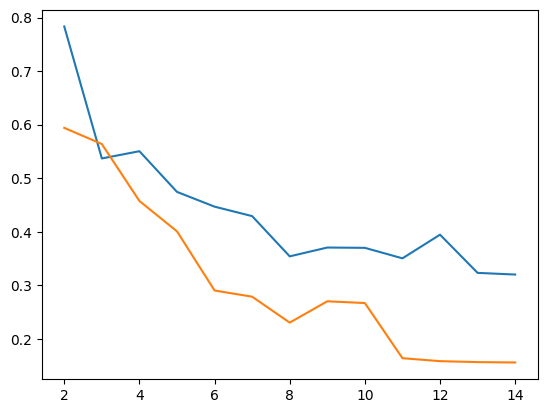

In [135]:
scores_chemprop = print_silhouette_scores(X_chemprop, k_max=15, metric='cosine')
scores_transformer = print_silhouette_scores(X_transformer, k_max=15, metric='cosine')

In [105]:
cluster_model = AgglomerativeClustering(
    n_clusters=12, 
    metric='cosine', 
    linkage='average'
)

labels_chemprop = cluster_model.fit_predict(X_chemprop)
labels_transformer = cluster_model.fit_predict(X_transformer)

unique_chemprop, counts_chemprop = np.unique(labels_chemprop, return_counts=True)
unique_transformer, counts_transformer = np.unique(labels_transformer, return_counts=True)

print(unique_chemprop, counts_chemprop)
print(unique_transformer, counts_transformer)

[ 0  1  2  3  4  5  6  7  8  9 10 11] [809   3 594 250   2  18 314   1   6   1   1   1]
[ 0  1  2  3  4  5  6  7  8  9 10 11] [   5   17    8    5   56   27    2  218 1656    4    1    1]


In [108]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init="pca")
X_c_tsne = tsne.fit_transform(X_chemprop)
X_t_tsne = tsne.fit_transform(X_transformer)

reducer = UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
X_c_umap = reducer.fit_transform(X_chemprop)
X_t_tsne = tsne.fit_transform(X_transformer)

pca = PCA(n_components=2, random_state=42)
X_c_pca = pca.fit_transform(X_chemprop)
X_t_tsne = tsne.fit_transform(X_transformer)

mds = MDS(n_components=2, random_state=42, normalized_stress='auto')
X_c_mds = mds.fit_transform(X_chemprop)
X_t_tsne = tsne.fit_transform(X_transformer)

/Users/karlfindhansen/Desktop/DTU/Kandidat/Thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/karlfindhansen/Desktop/DTU/Kandidat/Thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/Users/karlfindhansen/Desktop/DTU/Kandidat/Thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


In [109]:
properties = {
    "UMAP 1": X_c_tsne[:, 0],
    "UMAP 2": X_c_tsne[:, 1],
    "Cluster": labels_chemprop,
    "Structure": qm9.df["structure_class"].to_list(),
    "Functional Groups": qm9.df["functional_groups"].to_list(),
    "SP1 Carbon" : qm9.df["num_sp_carbons"].to_list(),
    "SP2 Carbon" : qm9.df["num_sp2_carbons"].to_list(),
    "SP3 Carbon" : qm9.df["num_sp3_carbons"].to_list(),
    "Avg Bond length": qm9.df["avg_bond_length"].to_list(),
}

widget = chemiscope.show(
    structures=frames,
    properties=properties,
)

widget

<ChemiscopeWidget(meta={'name': ' '}, structures=[{'size': 3, 'data': 'structure-0'}, {'size': 4, 'data': 'str…

In [110]:
properties = {
    "UMAP 1": X_t_tsne[:, 0],
    "UMAP 2": X_t_tsne[:, 1],
    "Cluster": labels_transformer,
    "Structure": qm9.df["structure_class"].to_list(),
    "Functional Groups": qm9.df["functional_groups"].to_list(),
    "SP1 Carbon" : qm9.df["num_sp_carbons"].to_list(),
    "SP2 Carbon" : qm9.df["num_sp2_carbons"].to_list(),
    "SP3 Carbon" : qm9.df["num_sp3_carbons"].to_list(),
    "Avg Bond length": qm9.df["avg_bond_length"].to_list(),
}

widget = chemiscope.show(
    structures=frames,
    properties=properties,
)

widget

<ChemiscopeWidget(meta={'name': ' '}, structures=[{'size': 3, 'data': 'structure-0'}, {'size': 4, 'data': 'str…

# ACSF

Processing number of clusters): 100%|██████████| 13/13 [00:00<00:00, 13.82it/s]

Best silhouette score is at: 2 being 0.8877595485692953


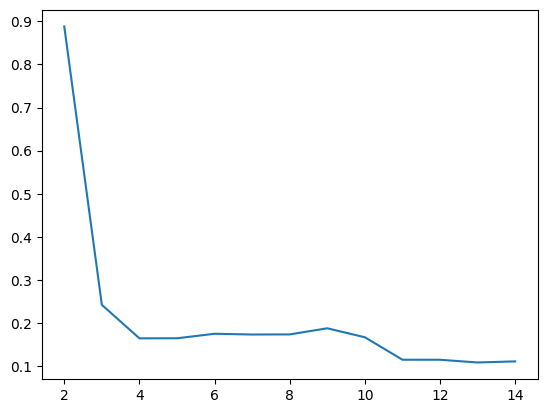

In [132]:
from sklearn.preprocessing import StandardScaler
X_acsf = np.array(qm9.df["acsf_embedding"].to_list())

scaler = StandardScaler()
X_acsf = scaler.fit_transform(X_acsf)

scores_chemprop = print_silhouette_scores(X_acsf, k_max=15, metric='euclidean', linkage='ward')

In [133]:
cluster_model = AgglomerativeClustering(
    n_clusters=2, 
    metric='euclidean', 
    linkage='ward'
)

labels_acsf = cluster_model.fit_predict(X_acsf)

unique_acsf, counts_acsf = np.unique(labels_acsf, return_counts=True)

print(unique_acsf, counts_acsf)

tsne = TSNE(n_components=2, perplexity=30, random_state=42, init="pca")
X_tsne = tsne.fit_transform(X_acsf)

reducer = UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_acsf)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_acsf)

mds = MDS(n_components=2, random_state=42, normalized_stress='auto')
X_mds = mds.fit_transform(X_acsf)

[0 1] [1994    6]


/Users/karlfindhansen/Desktop/DTU/Kandidat/Thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/karlfindhansen/Desktop/DTU/Kandidat/Thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/Users/karlfindhansen/Desktop/DTU/Kandidat/Thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


In [121]:
properties = {
    "UMAP 1": X_tsne[:, 0],
    "UMAP 2": X_tsne[:, 1],
    "Cluster": labels_acsf,
    "Structure": qm9.df["structure_class"].to_list(),
    "Functional Groups": qm9.df["functional_groups"].to_list(),
    "SP1 Carbon" : qm9.df["num_sp_carbons"].to_list(),
    "SP2 Carbon" : qm9.df["num_sp2_carbons"].to_list(),
    "SP3 Carbon" : qm9.df["num_sp3_carbons"].to_list(),
    "Avg Bond length": qm9.df["avg_bond_length"].to_list(),
}

widget = chemiscope.show(
    structures=frames,
    properties=properties,
)

widget

<ChemiscopeWidget(meta={'name': ' '}, structures=[{'size': 3, 'data': 'structure-0'}, {'size': 4, 'data': 'str…

# SOAP
- Using soap kernel

In [127]:
from sklearn.preprocessing import normalize
X_soap = np.array(qm9.df["soap_embedding"].to_list())
X_soap_normalized = normalize(X_soap, norm='l2', axis=1)

Processing number of clusters): 100%|██████████| 13/13 [00:36<00:00,  2.78s/it]

Best silhouette score is at: 2 being 0.29741235238229696


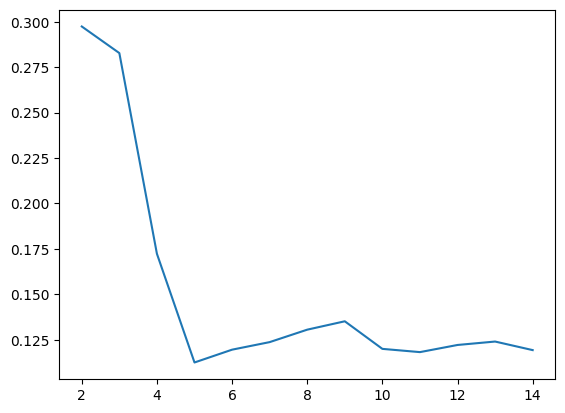

In [128]:
scores_chemprop = print_silhouette_scores(X_soap_normalized, k_max=15, metric='euclidean', linkage='ward')

In [130]:
cluster_model = AgglomerativeClustering(
    n_clusters=2, 
    metric='euclidean', 
    linkage='ward'
)

labels_soap = cluster_model.fit_predict(X_soap_normalized)

unique_soap, counts_soap = np.unique(labels_soap, return_counts=True)

print(unique_soap, counts_soap)

tsne = TSNE(n_components=2, perplexity=30, random_state=42, init="pca")
X_tsne = tsne.fit_transform(X_soap_normalized)

reducer = UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_soap_normalized)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_soap_normalized)

mds = MDS(n_components=2, random_state=42, normalized_stress='auto')
X_mds = mds.fit_transform(X_soap_normalized)

[0 1] [ 535 1465]


/Users/karlfindhansen/Desktop/DTU/Kandidat/Thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/karlfindhansen/Desktop/DTU/Kandidat/Thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/Users/karlfindhansen/Desktop/DTU/Kandidat/Thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


In [131]:
properties = {
    "UMAP 1": X_tsne[:, 0],
    "UMAP 2": X_tsne[:, 1],
    "Cluster": labels_soap,
    "Structure": qm9.df["structure_class"].to_list(),
    "Functional Groups": qm9.df["functional_groups"].to_list(),
    "SP1 Carbon" : qm9.df["num_sp_carbons"].to_list(),
    "SP2 Carbon" : qm9.df["num_sp2_carbons"].to_list(),
    "SP3 Carbon" : qm9.df["num_sp3_carbons"].to_list(),
    "Avg Bond length": qm9.df["avg_bond_length"].to_list(),
}

widget = chemiscope.show(
    structures=frames,
    properties=properties,
)

widget

<ChemiscopeWidget(meta={'name': ' '}, structures=[{'size': 3, 'data': 'structure-0'}, {'size': 4, 'data': 'str…